<a href="https://colab.research.google.com/github/aankitsharma/Machine-Learning-Models/blob/main/Car_Price_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement & Objective



Problem Statement

The automobile market has seen rapid growth, making it important for buyers, sellers, and dealerships to estimate the fair resale value of used cars accurately. The resale price of a car depends on multiple factors such as brand, model, manufacturing year, fuel type, transmission, kilometers driven, ownership history, and condition of the vehicle. However, manually estimating a car’s resale value can be difficult and often leads to inconsistent pricing.

This project aims to build a machine learning model to predict the resale value of Tata Motors cars based on historical car data and key vehicle attributes. By analyzing patterns in the dataset, the model will help provide accurate price predictions, enabling better decision-making for customers, dealers, and online car marketplaces.

Why this problem matters?
1. Helps sellers set a competitive and fair price.
2. Assists buyers in avoiding overpaying for used cars.
3. Supports dealerships in inventory valuation.
4. Improves transparency in the used car market.

# Objective

1. To analyze the factors affecting car resale prices : Identify important features such as car model, manufacturing year, fuel type, transmission, and kilometers driven that influence resale value.
2. To preprocess and clean the dataset : Handle missing values, outliers, and categorical variables to make the data suitable for machine learning models.
3. To perform exploratory data analysis (EDA): Understand data patterns, relationships, and trends between different car features and resale prices.
4. To build a predictive machine learning model: Develop and train regression models to accurately estimate the resale value of used Tata cars.
5. To evaluate model performance: Measure prediction accuracy using evaluation metrics such as MAE, MSE, RMSE, and R² score.
6. To identify the best-performing algorithm: Compare multiple machine learning models and select the most accurate one for price prediction.
7. To assist buyers and sellers in fair pricing decisions: Provide a reliable system that helps in estimating the market value of used cars.

# Eda and ML Model

In [264]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


In [265]:
#Load the dataset
df = pd.read_csv('car_price_prediction_.csv')

In [266]:
#Check the dataset
df.head()

,car_id,brand,model,variant,fuel_type,transmission,body_type,engine_cc,power_bhp,mileage_kmpl,ex_showroom_price_lakh,year,kilometers_driven,owner_count,accident_history,resale_price_lakh
0,1,Tata,Tiago,XE,Petrol,Manual,Hatchback,1199,85,20.1,5.7,2026,4978,2,1,4.48
1,2,Tata,Tiago,XE,Petrol,Manual,Hatchback,1199,85,20.1,5.7,2022,84605,2,0,3.18
2,3,Tata,Tiago,XE,Petrol,Manual,Hatchback,1199,85,20.1,5.7,2023,64915,2,0,3.18
3,4,Tata,Tiago,XE,Petrol,Manual,Hatchback,1199,85,20.1,5.7,2023,43577,1,0,4.06
4,5,Tata,Tiago,XE,Petrol,Manual,Hatchback,1199,85,20.1,5.7,2024,40448,3,0,3.43


In [267]:
#Check the null value
df.isnull().sum()

,0
car_id,0
brand,0
model,0
variant,0
fuel_type,0
transmission,0
body_type,0
engine_cc,0
power_bhp,0
mileage_kmpl,0


In [268]:
#Check the duplicated
df.duplicated().sum()

np.int64(0)

In [269]:
#dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   car_id                  3800 non-null   int64  
 1   brand                   3800 non-null   object 
 2   model                   3800 non-null   object 
 3   variant                 3800 non-null   object 
 4   fuel_type               3800 non-null   object 
 5   transmission            3800 non-null   object 
 6   body_type               3800 non-null   object 
 7   engine_cc               3800 non-null   int64  
 8   power_bhp               3800 non-null   int64  
 9   mileage_kmpl            3800 non-null   float64
 10  ex_showroom_price_lakh  3800 non-null   float64
 11  year                    3800 non-null   int64  
 12  kilometers_driven       3800 non-null   int64  
 13  owner_count             3800 non-null   int64  
 14  accident_history        3800 non-null   

In [270]:
#dataset overview
df.describe()

,car_id,engine_cc,power_bhp,mileage_kmpl,ex_showroom_price_lakh,year,kilometers_driven,owner_count,accident_history,resale_price_lakh
count,3800.00000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000
mean,1900.50000,1389.736842,106.736842,19.621053,11.063158,2023.032368,48849.491579,1.356316,0.106579,7.580789
std,1097.10984,305.996375,33.943797,3.354399,5.740204,1.992947,31465.233216,0.571672,0.308618,4.774402
min,1.00000,1199.000000,72.000000,14.500000,5.700000,2020.000000,4001.000000,1.000000,0.000000,1.500000
25%,950.75000,1199.000000,85.000000,17.200000,7.000000,2021.000000,23208.250000,1.000000,0.000000,4.400000
50%,1900.50000,1199.000000,87.000000,19.300000,9.000000,2023.000000,45842.000000,1.000000,0.000000,6.160000
75%,2850.25000,1497.000000,118.000000,20.300000,13.500000,2025.000000,70089.250000,2.000000,0.000000,9.000000
max,3800.00000,1956.000000,168.000000,26.900000,27.000000,2026.000000,129855.000000,3.000000,1.000000,27.250000


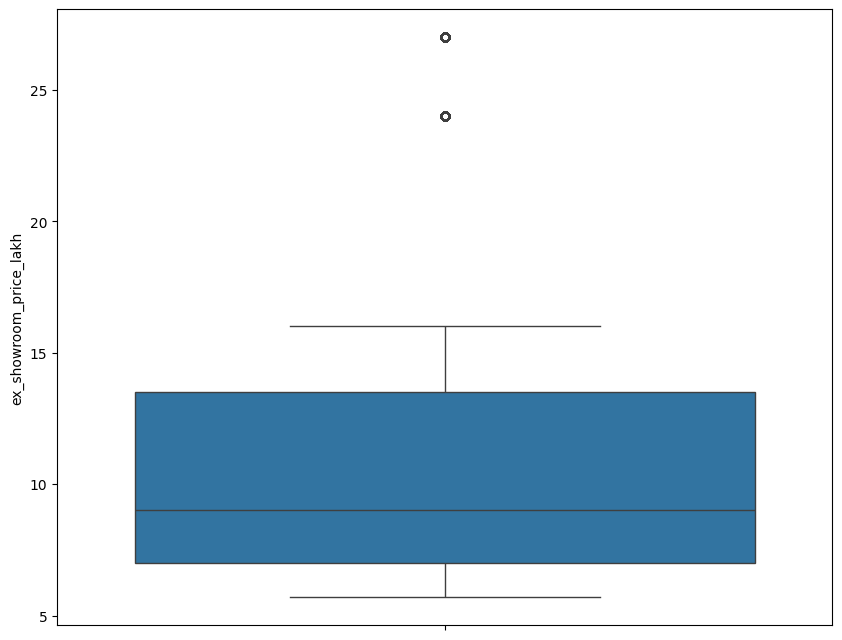

In [271]:
#check the outliers
plt.figure(figsize=(10,8))
sns.boxplot(df.ex_showroom_price_lakh)
plt.show()

#there are few outliers which are genuine because some cars may have high values

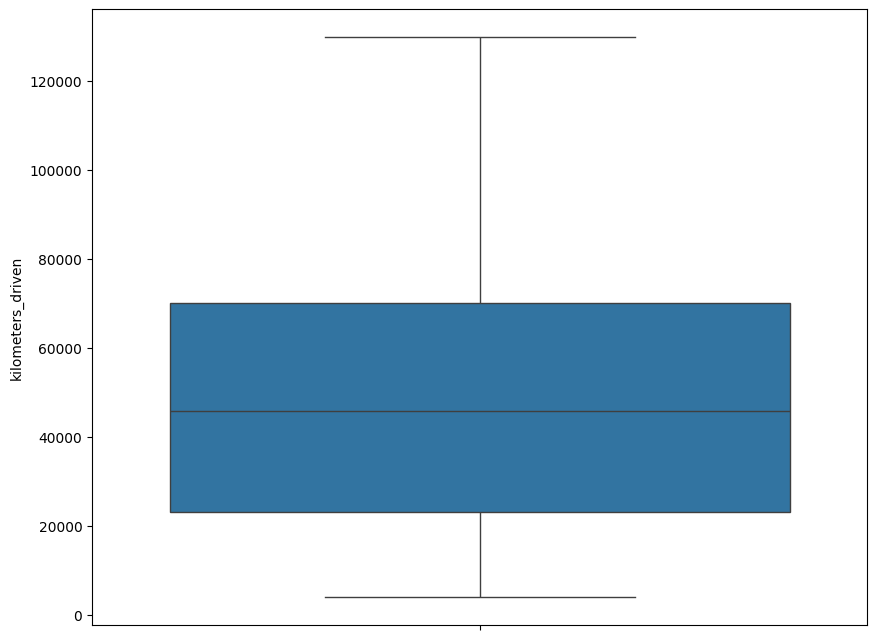

In [272]:
plt.figure(figsize=(10,8))
sns.boxplot(df.kilometers_driven)
plt.show()

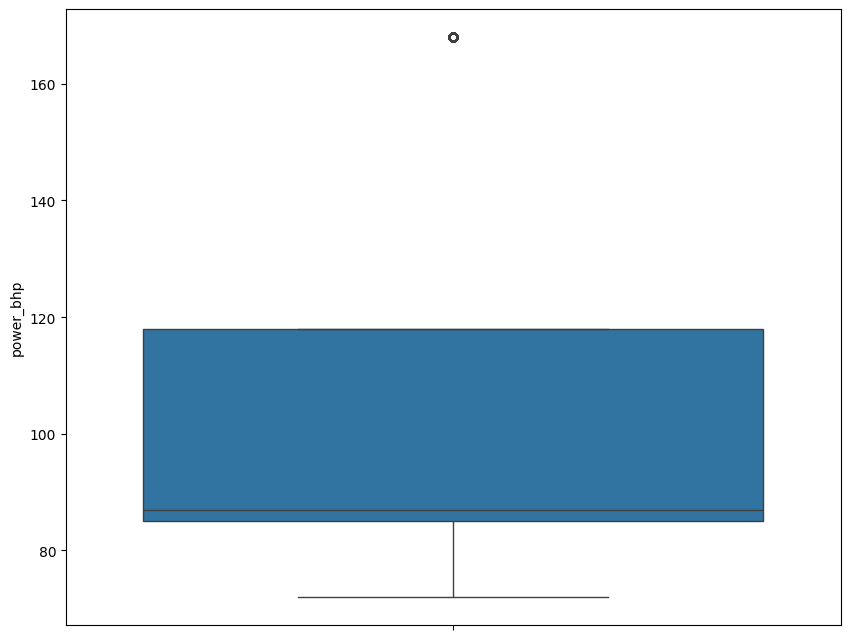

In [273]:
plt.figure(figsize=(10,8))
sns.boxplot(df.power_bhp)
plt.show()

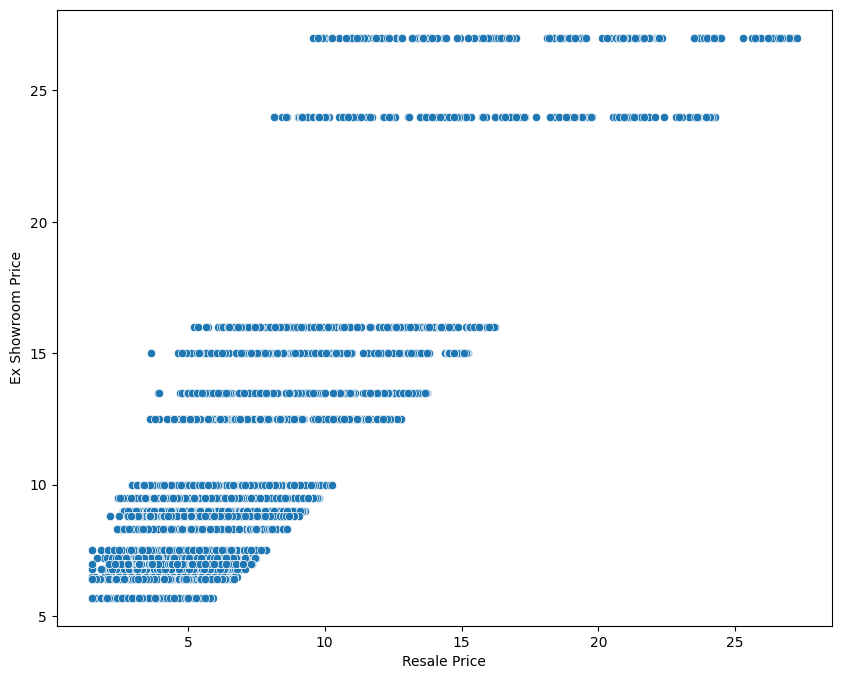

In [274]:
#Relatinship between power and ex_showroom price
plt.figure(figsize=(10,8))
sns.scatterplot(x=df.resale_price_lakh,y=df.ex_showroom_price_lakh)
plt.xlabel('Resale Price')
plt.ylabel('Ex Showroom Price')
plt.show()



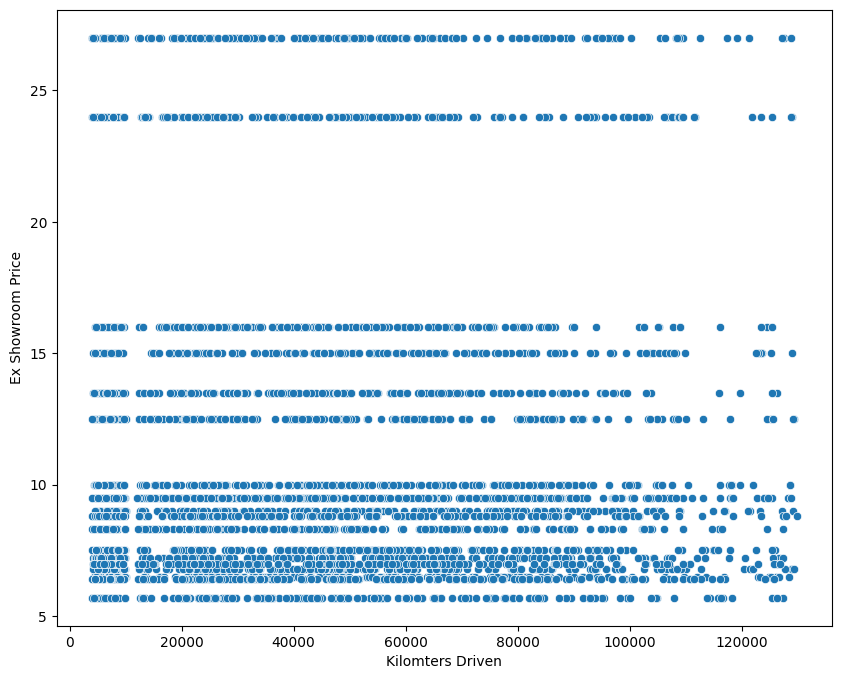

In [275]:
#Relation ship between car driven and ex_showroom price
plt.figure(figsize=(10,8))
sns.scatterplot(x=df.kilometers_driven,y=df.ex_showroom_price_lakh)
plt.xlabel('Kilomters Driven')
plt.ylabel('Ex Showroom Price')
plt.show()


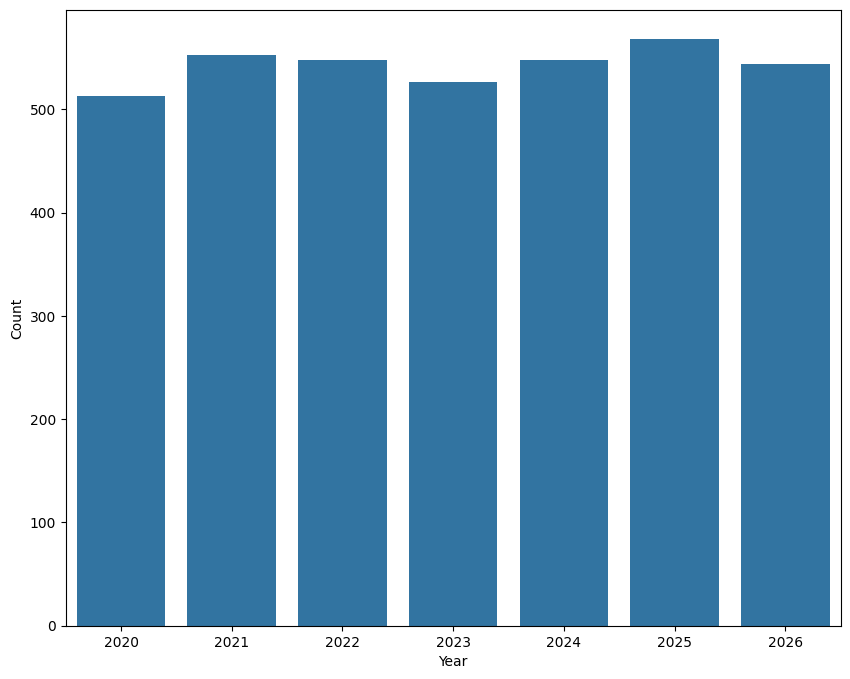

In [276]:
#Distribution of cars through out the years
plt.figure(figsize=(10,8))
sns.countplot(x=df.year)
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

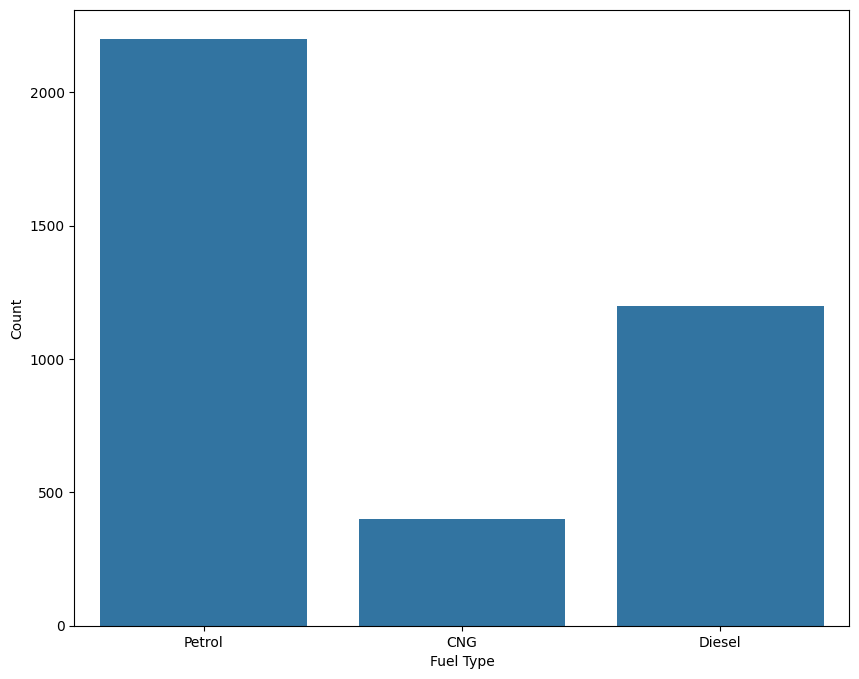

In [277]:
#Types of cars
plt.figure(figsize=(10,8))
sns.countplot(x=df.fuel_type)
plt.xlabel('Fuel Type')
plt.ylabel('Count')
plt.show()

In [278]:
df

,car_id,brand,model,variant,fuel_type,transmission,body_type,engine_cc,power_bhp,mileage_kmpl,ex_showroom_price_lakh,year,kilometers_driven,owner_count,accident_history,resale_price_lakh
0,1,Tata,Tiago,XE,Petrol,Manual,Hatchback,1199,85,20.1,5.7,2026,4978,2,1,4.48
1,2,Tata,Tiago,XE,Petrol,Manual,Hatchback,1199,85,20.1,5.7,2022,84605,2,0,3.18
2,3,Tata,Tiago,XE,Petrol,Manual,Hatchback,1199,85,20.1,5.7,2023,64915,2,0,3.18
3,4,Tata,Tiago,XE,Petrol,Manual,Hatchback,1199,85,20.1,5.7,2023,43577,1,0,4.06
4,5,Tata,Tiago,XE,Petrol,Manual,Hatchback,1199,85,20.1,5.7,2024,40448,3,0,3.43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3795,3796,Tata,Safari,Accomplished AT,Diesel,Automatic,SUV,1956,168,14.5,27.0,2025,13895,1,0,23.99
3796,3797,Tata,Safari,Accomplished AT,Diesel,Automatic,SUV,1956,168,14.5,27.0,2020,76772,2,0,11.18
3797,3798,Tata,Safari,Accomplished AT,Diesel,Automatic,SUV,1956,168,14.5,27.0,2022,69006,1,0,15.78
3798,3799,Tata,Safari,Accomplished AT,Diesel,Automatic,SUV,1956,168,14.5,27.0,2026,8956,1,0,26.64


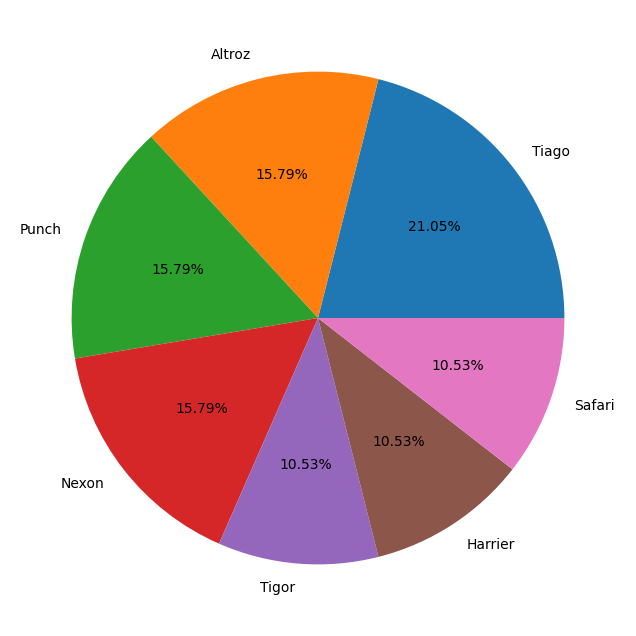

In [279]:
#Type of cars model
plt.figure(figsize=(10,8))
plt.pie(df.model.value_counts(),labels=df.model.value_counts().index,autopct='%1.2f%%')
plt.show()

#Insight

1. Resale Price vs Ex-showroom Price

Weak relationship between resale price and ex-showroom price.

Resale value depends more on age, km driven, fuel type, etc.

2. Fuel Type Distribution

Petrol cars have the highest count.

Diesel is second, while CNG has the lowest count.

Petrol dominates the used car market.

3. Top Car Models

Tiago has the highest share (21.05%).

Altroz, Punch, and Nexon follow equally.

Tigor, Harrier, and Safari have lower representation.

# Feature Engineering and Model Selection

In [280]:
df

,car_id,brand,model,variant,fuel_type,transmission,body_type,engine_cc,power_bhp,mileage_kmpl,ex_showroom_price_lakh,year,kilometers_driven,owner_count,accident_history,resale_price_lakh
0,1,Tata,Tiago,XE,Petrol,Manual,Hatchback,1199,85,20.1,5.7,2026,4978,2,1,4.48
1,2,Tata,Tiago,XE,Petrol,Manual,Hatchback,1199,85,20.1,5.7,2022,84605,2,0,3.18
2,3,Tata,Tiago,XE,Petrol,Manual,Hatchback,1199,85,20.1,5.7,2023,64915,2,0,3.18
3,4,Tata,Tiago,XE,Petrol,Manual,Hatchback,1199,85,20.1,5.7,2023,43577,1,0,4.06
4,5,Tata,Tiago,XE,Petrol,Manual,Hatchback,1199,85,20.1,5.7,2024,40448,3,0,3.43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3795,3796,Tata,Safari,Accomplished AT,Diesel,Automatic,SUV,1956,168,14.5,27.0,2025,13895,1,0,23.99
3796,3797,Tata,Safari,Accomplished AT,Diesel,Automatic,SUV,1956,168,14.5,27.0,2020,76772,2,0,11.18
3797,3798,Tata,Safari,Accomplished AT,Diesel,Automatic,SUV,1956,168,14.5,27.0,2022,69006,1,0,15.78
3798,3799,Tata,Safari,Accomplished AT,Diesel,Automatic,SUV,1956,168,14.5,27.0,2026,8956,1,0,26.64


In [281]:
#Convert Fuel type and transmission into numerical columns

df['transmission'] = df['transmission'].map({'Manual':0,'Automatic':1})

In [282]:
#Convert Categorical columns into numerical columns
df = pd.get_dummies(df,columns=['variant','model','body_type','fuel_type'],dtype=int)

In [283]:
df

,car_id,brand,transmission,engine_cc,power_bhp,mileage_kmpl,ex_showroom_price_lakh,year,kilometers_driven,owner_count,...,model_Tigor,body_type_Compact SUV,body_type_Hatchback,body_type_Micro SUV,body_type_Mid-Size SUV,body_type_SUV,body_type_Sedan,fuel_type_CNG,fuel_type_Diesel,fuel_type_Petrol
0,1,Tata,0,1199,85,20.1,5.7,2026,4978,2,...,0,0,1,0,0,0,0,0,0,1
1,2,Tata,0,1199,85,20.1,5.7,2022,84605,2,...,0,0,1,0,0,0,0,0,0,1
2,3,Tata,0,1199,85,20.1,5.7,2023,64915,2,...,0,0,1,0,0,0,0,0,0,1
3,4,Tata,0,1199,85,20.1,5.7,2023,43577,1,...,0,0,1,0,0,0,0,0,0,1
4,5,Tata,0,1199,85,20.1,5.7,2024,40448,3,...,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3795,3796,Tata,1,1956,168,14.5,27.0,2025,13895,1,...,0,0,0,0,0,1,0,0,1,0
3796,3797,Tata,1,1956,168,14.5,27.0,2020,76772,2,...,0,0,0,0,0,1,0,0,1,0
3797,3798,Tata,1,1956,168,14.5,27.0,2022,69006,1,...,0,0,0,0,0,1,0,0,1,0
3798,3799,Tata,1,1956,168,14.5,27.0,2026,8956,1,...,0,0,0,0,0,1,0,0,1,0


In [284]:
#Split data into train and test
X = df.drop(['car_id','brand','resale_price_lakh','ex_showroom_price_lakh'],axis=1)
y = df['resale_price_lakh']

In [285]:
X_train,X_test,y_train,y_test =train_test_split(X,y,random_state = 42,test_size = 0.2)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3040, 39)
(760, 39)
(3040,)
(760,)


In [286]:
#Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [287]:
#run the Linear Regression Model
lr = LinearRegression()
lr.fit(X_train_scaled,y_train)

LinearRegression()

In [288]:
#Predict the price
y_pred = lr.predict(X_test_scaled)

In [289]:
#Evaluation Metrics
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
print('Mean Squared Error:',mse)
print('Root Mean Squared Error:',rmse)
print('R2 Score:',r2)

Mean Squared Error: 1.3529303025827542
Root Mean Squared Error: 1.1631553217789765
R2 Score: 0.9425389850022966


In [290]:
#Run the Random Forest Model
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
rf = RandomForestRegressor()

rf_params = {'n_estimators':[50,100,200],
             'max_depth':[5,10,15],
             'min_samples_split':[5,10,15],
             'min_samples_leaf':[5,10,15]}

rf_grid = GridSearchCV(rf,param_grid=rf_params,cv=5,verbose=1,n_jobs=-1)
rf_grid.fit(X_train,y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15],
                         'min_samples_leaf': [5, 10, 15],
                         'min_samples_split': [5, 10, 15],
                         'n_estimators': [50, 100, 200]},
             verbose=1)

In [291]:
y_pred_rf= rf_grid.predict(X_test)

In [292]:
mse_rf = mean_squared_error(y_test,y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test,y_pred_rf)
print('Mean Squared Error:',mse_rf)
print('Root Mean Squared Error:',rmse_rf)
print('R2 Score:',r2_rf)

Mean Squared Error: 0.11968233460319556
Root Mean Squared Error: 0.3459513471619898
R2 Score: 0.9949169085721076


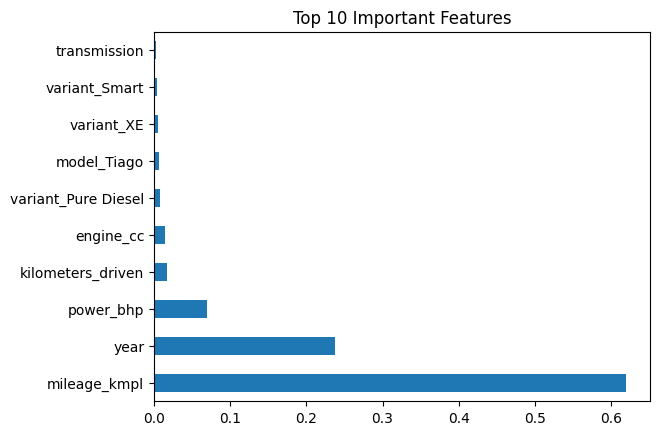

In [293]:
importances = rf_grid.best_estimator_.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns)
feat_imp.nlargest(10).plot(kind='barh')
plt.title('Top 10 Important Features')
plt.show()

# Conclusion

In this project, two machine learning models were developed to predict the resale value of Tata Motors cars based on features such as model, body type, variant, fuel type, year, kilometers driven, owner count, and accident history.
The Linear Regression model achieved an R² score of 94.25% with an RMSE of ₹1.16 lakh, serving as a strong baseline. The Random Forest model with GridSearchCV tuning performed significantly better, achieving an R² score of 99.49% with an RMSE of only ₹0.35 lakh.

Random Forest was selected as the final model due to its ability to capture non-linear relationships between features and resale price. The low RMSE suggests the model can estimate used car prices within a reasonable margin, making it potentially useful for buyers, sellers, and dealerships.


Limitation: The dataset consists entirely of Tata Motors vehicles and may be synthetically generated, which could explain the high R² values. Performance on real-world diverse used car data may vary.